In [1]:
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from rasterio.warp import reproject, Resampling
from osgeo import gdal
gdal.UseExceptions()
import importlib
import model_comparison_functions
importlib.reload(model_comparison_functions)
from model_comparison_functions import process_all_dates, get_raw_data

In [2]:
task1_raw_data = get_raw_data("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 1)
task2_raw_data = get_raw_data("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 2)
task1 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 1)
task2 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 2)

In [42]:
dem_100_fp = "C:/Users/RDCRLSMC/Desktop/SIRO/data/shapes/dem_bil_100.tif"
dem_2000_fp = "C:/Users/RDCRLSMC/Desktop/SIRO/data/shapes/dem_bil_2000.tif"

dfs = []


for key in task1.keys():
    task1_clip = task1[key]['basin_clip']
    task2_clip = task2[key]['basin_clip']

    MCS = {"Task 1":task1_clip, "Task 2":task2_clip}

    for task, raster_list in MCS.items():
        for name, model_data in raster_list.items():
                with rasterio.open(model_data) as src:
                    ref_shape = (src.height, src.width)
                    ref_transform = src.transform
                    data = src.read(1)
                    # mask = (data == -9999)
                    # data_masked = np.ma.array(data, mask=mask)
                    # flattened = data_masked.compressed()
                    # flattened = flattened[flattened < 5]

                elevation_aligned = np.empty(ref_shape, dtype=np.float32)

                if 'HMS' in name:

                    with rasterio.open(dem_2000_fp) as dem:
                        reproject(
                            source=dem.read(1),
                            destination=elevation_aligned,
                            src_transform=dem.transform,
                            src_crs=dem.crs,
                            dst_transform=ref_transform,
                            dst_crs="EPSG:32611",
                            resampling=Resampling.nearest
                        )
                else:

                    with rasterio.open(dem_100_fp) as dem:
                        reproject(
                            source=dem.read(1),
                            destination=elevation_aligned,
                            src_transform=dem.transform,
                            src_crs=dem.crs,
                            dst_transform=ref_transform,
                            dst_crs="EPSG:32611",
                            resampling=Resampling.nearest
                        )

                invalid_snow = (data == -9999)
                invalid_elev = (elevation_aligned == 0)
                master_mask = invalid_snow | invalid_elev

                data_masked = np.ma.array(data, mask=master_mask)
                elevation_masked = np.ma.array(elevation_aligned, mask=master_mask)

                # Compress them (they are guaranteed to be the same length now)
                flattened = data_masked.compressed()
                elevation_flat = elevation_masked.compressed()

                df = pd.DataFrame({
                "Task":task,
                "Date":key,
                "Model": name,        # this column will store model names
                "Snow Depth": flattened,
                "Elevation": elevation_flat,
                })
                dfs.append(df)


snow_depth = pd.concat(dfs, ignore_index=True)

In [43]:
Task1_basin = snow_depth[snow_depth['Task'] =='Task 1']
Task2_basin = snow_depth[snow_depth['Task'] =='Task 2']

In [46]:
snow_depth

,Task,Date,Model,Snow Depth,Elevation,Elevation Bin,Elevation Plot
0,Task 1,20230405,HMS-EB,0.867552,1855.005737,"(1800.0, 1900.0]",1850.0
1,Task 1,20230405,HMS-EB,1.003043,1896.164429,"(1800.0, 1900.0]",1850.0
2,Task 1,20230405,HMS-EB,0.575831,1499.287842,"(1400.0, 1500.0]",1450.0
3,Task 1,20230405,HMS-EB,0.883245,1728.824951,"(1700.0, 1800.0]",1750.0
4,Task 1,20230405,HMS-EB,1.083612,1981.512817,"(1900.0, 2000.0]",1950.0
...,...,...,...,...,...,...,...
2063945,Task 2,20250501,SnowModel,0.000000,1446.490845,"(1400.0, 1500.0]",1450.0
2063946,Task 2,20250501,SnowModel,0.000000,1456.453735,"(1400.0, 1500.0]",1450.0
2063947,Task 2,20250501,SnowModel,0.000000,1446.656982,"(1400.0, 1500.0]",1450.0
2063948,Task 2,20250501,SnowModel,0.000000,1433.634521,"(1400.0, 1500.0]",1450.0


bins: 16 (edges: 900 to 2500 m, width 100 m)


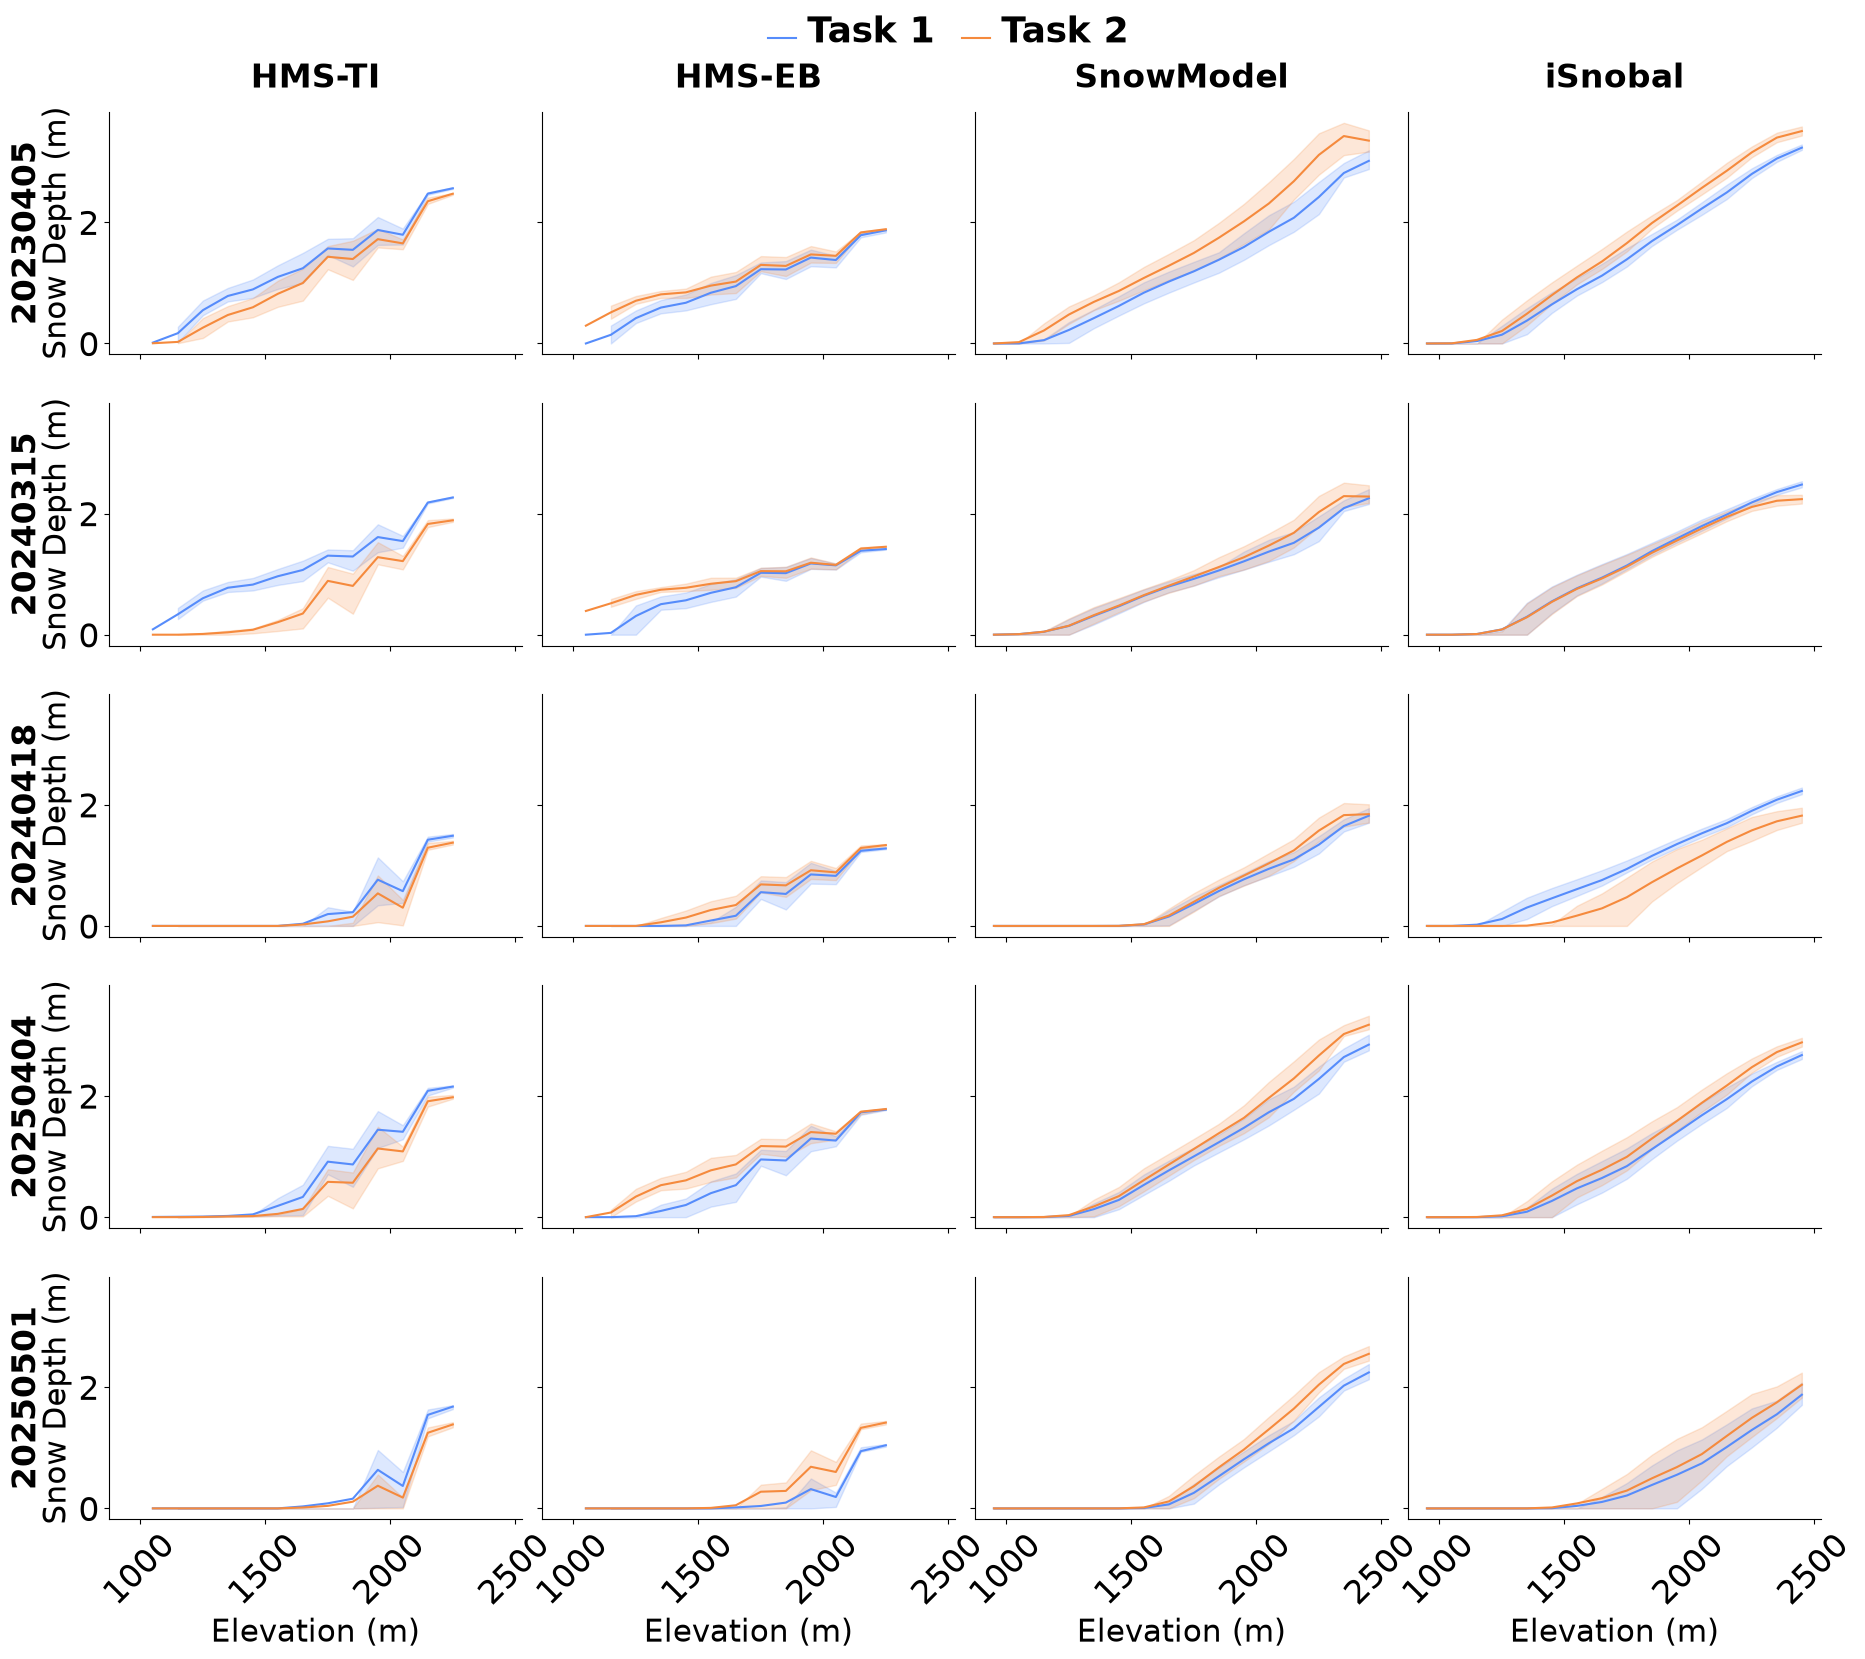

In [48]:
#create empty column for elevation bin
snow_depth['Elevation Bin'] = pd.Series(pd.NA, index=snow_depth.index, dtype='object')

# Build 100-m-wide bins
min = np.floor(snow_depth['Elevation'].min() / 100) * 100
max = np.ceil(snow_depth['Elevation'].max() / 100) * 100
edges = np.arange(min, max + 100, 100)

print(f"bins: {len(edges) - 1} (edges: {edges[0]:.0f} to {edges[-1]:.0f} m, width 100 m)")

snow_depth['Elevation Bin'] = pd.cut(snow_depth['Elevation'], bins=edges).astype(object).values

# 2. Extract the numeric midpoint of the bin for the X-axis plotting
snow_depth['Elevation Plot'] = snow_depth['Elevation Bin'].apply(lambda x: x.mid).astype(float)

col_order = ['HMS-TI', 'HMS-EB', 'SnowModel', 'iSnobal']
row_order = sorted(snow_depth['Date'].unique())

g = sns.relplot(
    data=snow_depth,
    x='Elevation Plot',
    y='Snow Depth',
    row='Date',
    col='Model',
    row_order=row_order,
    col_order=col_order,
    hue='Task',
    kind='line',
    estimator='mean',
    errorbar=('pi', 50),
    height=3,
    aspect=1.5,
    facet_kws={'sharey': True, 'sharex': True}
)

g.figure.subplots_adjust(
    wspace=0.05,   # default is much larger (~0.2–0.3)
    hspace=0.2
)

# Optional: makes sure labels don't get clipped
g.set_axis_labels("Elevation (m)", "Snow Depth (m)", fontsize=22)
g.tick_params(axis='x', labelsize=24, rotation=45)
g.tick_params(axis='y', labelsize=24)
g.set_titles("")

row_labels = row_order
for i, ax in enumerate(g.axes[:, 0]):
    ax.annotate(
        row_labels[i],
        xy=(-.2, 0.5),
        xycoords='axes fraction',
        rotation=90,
        va='center',
        ha='center',
        fontsize=24,
        fontweight='bold'
    )

col_labels = col_order
for i, ax in enumerate(g.axes[0, :]):
    ax.annotate(
        col_labels[i],
        xy=(0.5, 1.1),
        xycoords='axes fraction',
        ha='center',
      #  va='bottom',
        fontsize=24,
        fontweight='bold'
    )

sns.move_legend(g, "upper center", bbox_to_anchor=(0.48, 1.05), ncol=2, markerscale=5)
plt.setp(g.legend.get_texts(), fontsize=26, fontweight='bold')
g.legend.set_title("")
plt.savefig("C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/ribbon_plots_both.png", dpi=300,
            bbox_inches="tight")
plt.show()